# Project Solutions

The following sections contain solutions to a subset of the questions that was given in the project

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# Question 6, 7, 8

## Figure F03

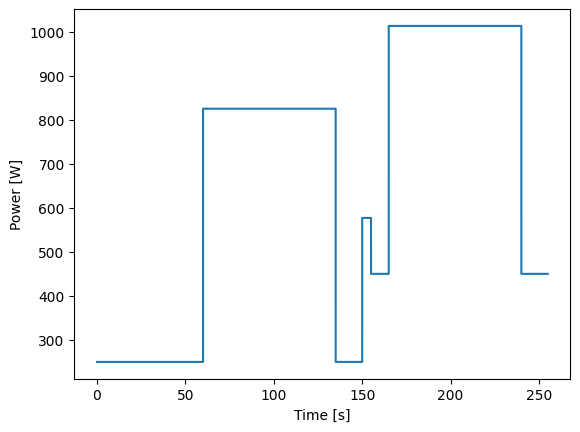

In [2]:
time = [0, 60, 60.01, 135, 135.01, 150, 150.01, 155, 155.01, 165, 165.01, 240, 240.01, 255]
power_req = [250, 250, 825, 825, 250, 250, 577, 577, 450, 450, 1013, 1013, 450, 450]
plt.plot(time, power_req)
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")

energy_J = np.trapz(power_req, time)
energy_kWh = energy_J / (3600 * 1000)

In [3]:
import math

def generate_repeated_cycle(base_time, base_power, total_duration_hours):    
    total_duration_seconds = total_duration_hours * 3600
    cycle_duration = base_time[-1]
    
    full_time_list = []
    full_power_list = []
    
    cycle_start_time = 0
    
    while cycle_start_time < total_duration_seconds:
        for i in range(len(base_time)):
            absolute_time = cycle_start_time + base_time[i]
            if absolute_time > total_duration_seconds:
                break
                
            full_time_list.append(absolute_time)
            full_power_list.append(base_power[i])
            
        cycle_start_time += cycle_duration

    if full_time_list and full_time_list[-1] < total_duration_seconds:
        full_time_list.append(total_duration_seconds)
        full_power_list.append(full_power_list[-1])

    return full_time_list, full_power_list


In [4]:
time_cycle = [0, 60, 60.01, 135, 135.01, 150, 150.01, 155, 155.01, 165, 165.01, 240, 240.01, 255]
power_cycle = [250, 250, 825, 825, 250, 250, 577, 577, 450, 450, 1013, 1013, 450, 450]

# Run the logic
target_hours = 3.5
extended_time, extended_power = generate_repeated_cycle(time_cycle, power_cycle, target_hours)

In [5]:
energy_J = np.trapz(extended_power, extended_time)
energy_kWh = energy_J / (3600 * 1000)
print("Total energy required (kWh): ", energy_kWh)

Total energy required (kWh):  2.3383578125


In [6]:
molicel_power_capacity = 16.2 #spec sheet Wh
molicel_peak_power = 130 # 180 - 90% SOC - 10s, this is estimate of continuous

LG_power_capacity = 18.2 #spec sheet - Wh
LG_peak_power = 40 # pulse - 80 W - 10s, this is estimate of continuous

n_cells_moli = energy_kWh * 1000 / molicel_power_capacity
n_cells_power_moli = max(extended_power)/ molicel_peak_power
print(f"Molicel P45B \n Energy limited case: {np.ceil(n_cells_moli)}, Power limited case: {np.ceil(n_cells_power_moli)}")

n_cells_lg = energy_kWh * 1000 / LG_power_capacity
n_cells_power_lg = max(extended_power)/LG_peak_power
print(f"LG-M50 \n Energy limited case: {np.ceil(n_cells_lg)}, Power limited case: {np.ceil(n_cells_power_lg)}")

Molicel P45B 
 Energy limited case: 145.0, Power limited case: 8.0
LG-M50 
 Energy limited case: 129.0, Power limited case: 26.0


Thus we see that for the humanoid robot case (Figure F03), for both cells we are limited by the energy. (We need more cells to meet the energy requirement as opposed to the peak power requirement).

### LG-M50

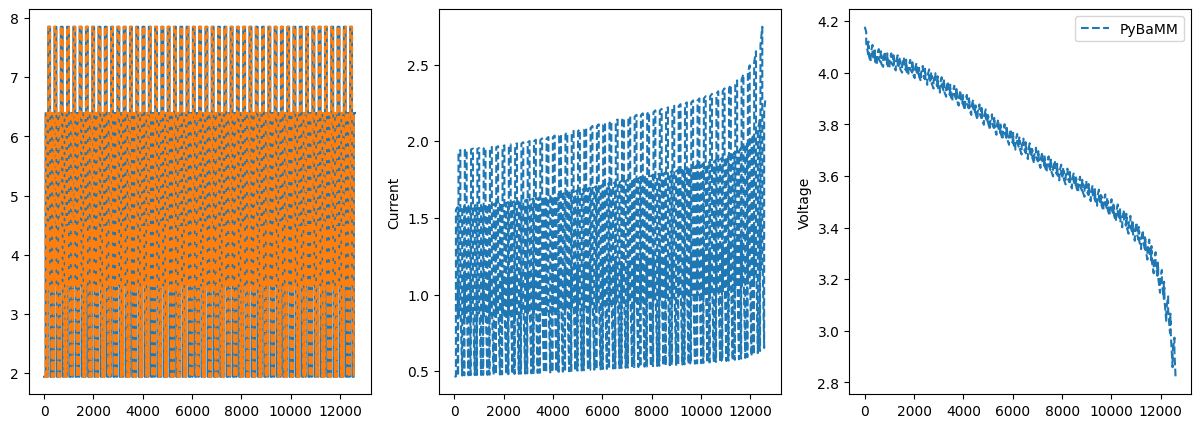

In [7]:
from params_lgm50 import get_parameter_values as lg_param_values

power_cell = np.array(extended_power) / np.ceil(n_cells_lg)

power_interpolant = pybamm.Interpolant(np.array(extended_time), power_cell, pybamm.t)
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})
params = lg_param_values()
params.update({"Power function [W]": power_interpolant}, check_already_exists=False)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=params, solver=solver)
soln = sim.solve(t_eval=np.array(extended_time), t_interp=np.array(extended_time), initial_soc=1.0)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(extended_time, power_cell)
ax[0].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries*soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Power")
ax[1].plot(soln["Time [s]"].entries, soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Current")
ax[2].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="PyBaMM", linestyle="--")
ax[2].set_ylabel("Voltage")
plt.legend()
plt.show()

Text(0, 0.5, 'Positive electrode potential [V]')

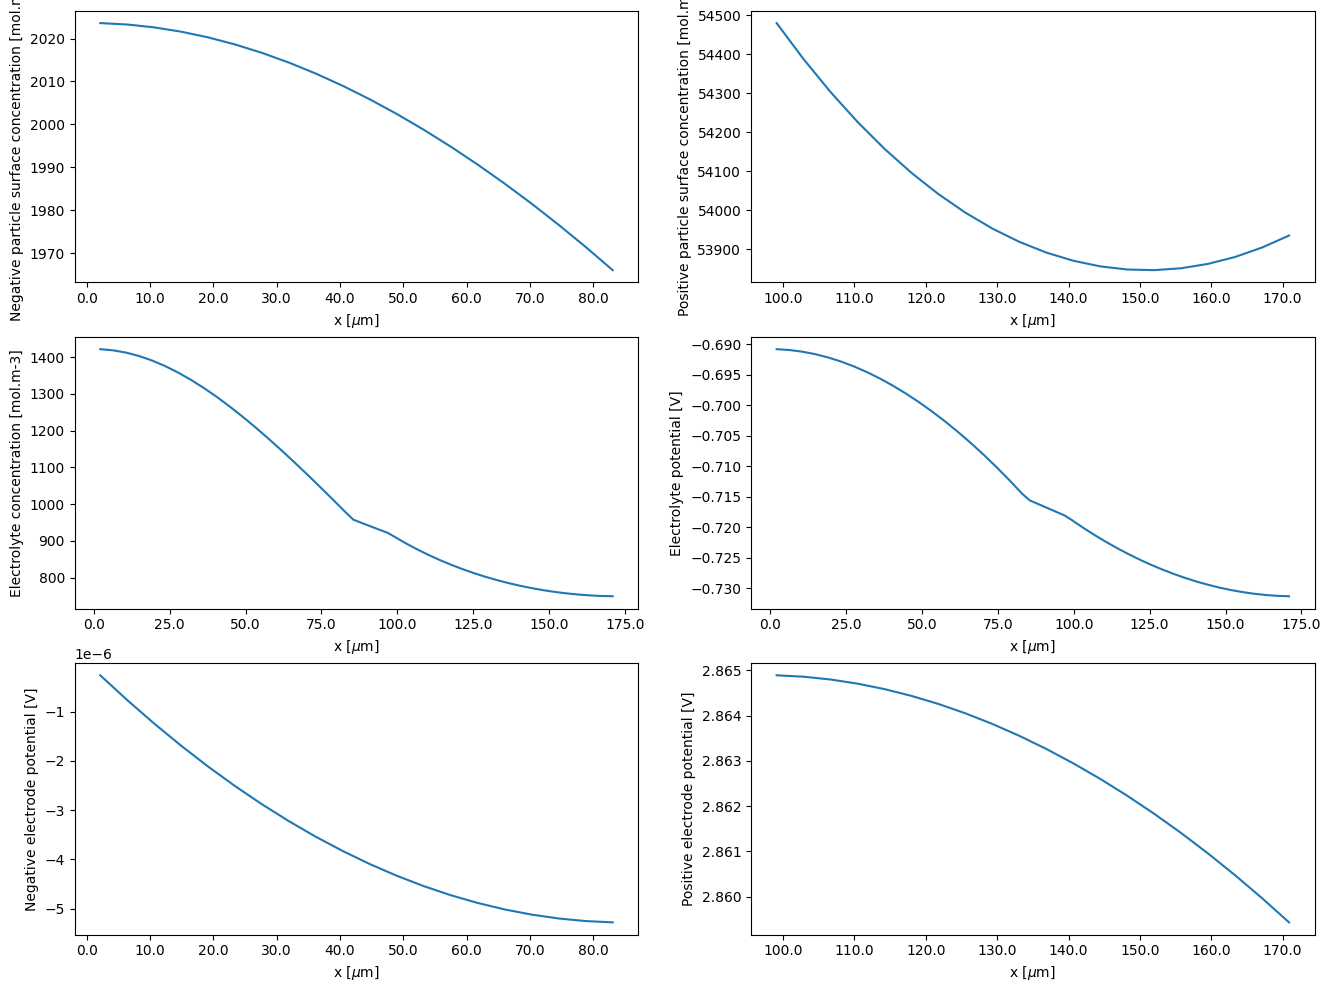

In [8]:
import matplotlib.ticker as ticker
idx_max_current = np.argmax(soln["Current [A]"].entries)
fig, ax = plt.subplots(3, 2, figsize=(16, 12))

x_mesh = np.concatenate((sim.mesh["negative electrode"].nodes, sim.mesh["separator"].nodes, sim.mesh["positive electrode"].nodes))
pos_mesh = sim.mesh["positive electrode"].nodes
neg_mesh = sim.mesh["negative electrode"].nodes

formatter = lambda x, pos: f'{x:.1f}'
for axis in ax.ravel():
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(formatter))
    axis.set_xlabel(r"x [$\mu$m]")

ax[0][1].plot(pos_mesh*10**6, soln["Positive particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][1].set_ylabel("Positive particle surface concentration [mol.m-3]")

ax[0][0].plot(neg_mesh*10**6, soln["Negative particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][0].set_ylabel("Negative particle surface concentration [mol.m-3]")

ax[1][0].plot(x_mesh*10**6, soln["Electrolyte concentration [mol.m-3]"].entries[:, idx_max_current])
ax[1][0].set_ylabel("Electrolyte concentration [mol.m-3]")


ax[1][1].plot(x_mesh*10**6, soln["Electrolyte potential [V]"].entries[:, idx_max_current])
ax[1][1].set_ylabel("Electrolyte potential [V]")

ax[2][0].plot(neg_mesh*10**6, soln["Negative electrode potential [V]"].entries[:, idx_max_current])
ax[2][0].set_ylabel("Negative electrode potential [V]")


ax[2][1].plot(pos_mesh*10**6, soln["Positive electrode potential [V]"].entries[:, idx_max_current])
ax[2][1].set_ylabel("Positive electrode potential [V]")




### Molicel P45B

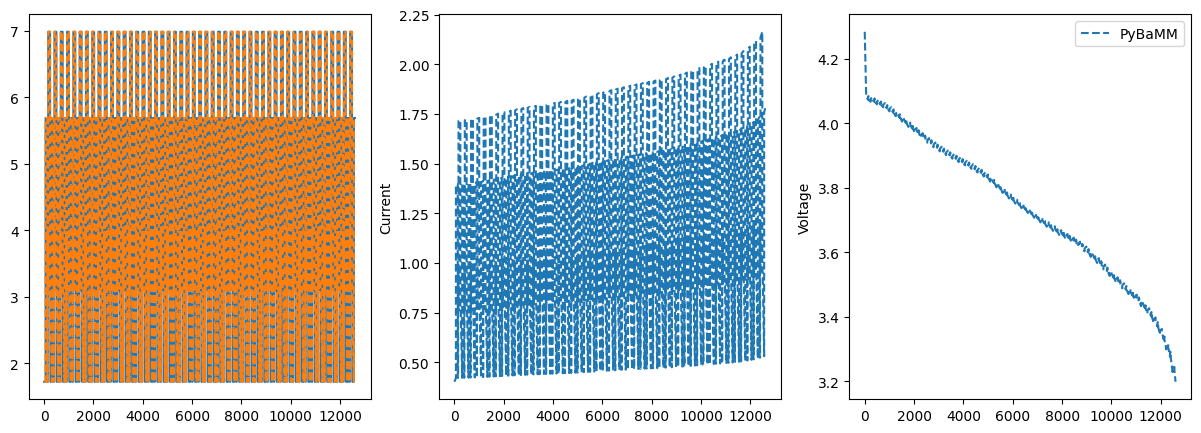

In [9]:
from params_p45b import get_parameter_values as p45b_param_values

power_cell = np.array(extended_power) / np.ceil(n_cells_moli)

power_interpolant = pybamm.Interpolant(np.array(extended_time), power_cell, pybamm.t)
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})
params = p45b_param_values()
params.update({"Power function [W]": power_interpolant}, check_already_exists=False)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=params, solver=solver)
soln = sim.solve(t_eval=np.array(extended_time), t_interp=np.array(extended_time), initial_soc=1.0)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(extended_time, power_cell)
ax[0].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries*soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Power")
ax[1].plot(soln["Time [s]"].entries, soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Current")
ax[2].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="PyBaMM", linestyle="--")
ax[2].set_ylabel("Voltage")
plt.legend()
plt.show()

Text(0, 0.5, 'Positive electrode potential [V]')

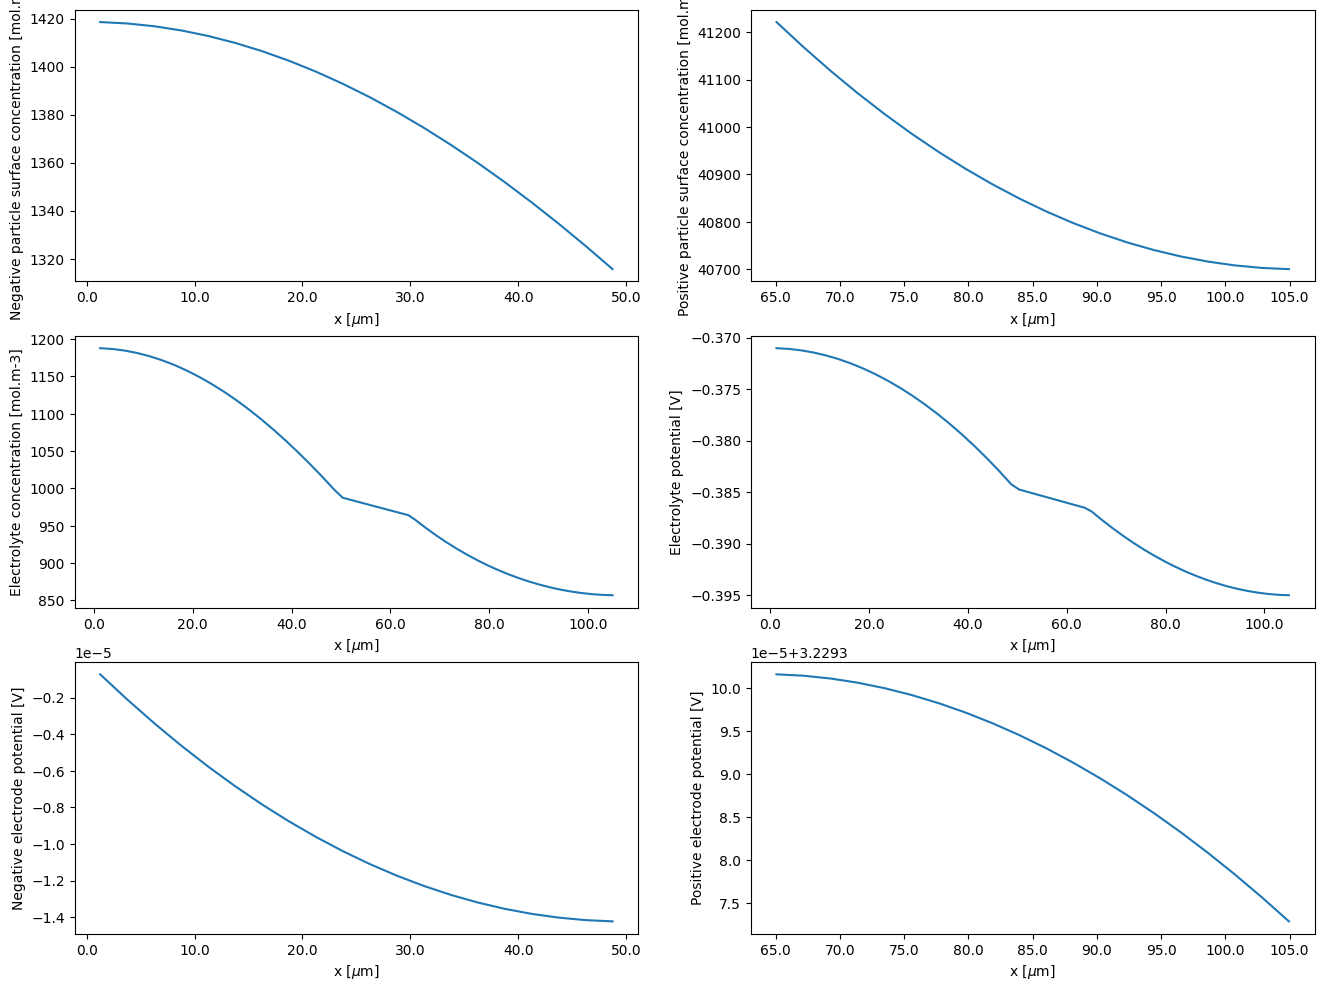

In [10]:
idx_max_current = np.argmax(soln["Current [A]"].entries)
fig, ax = plt.subplots(3, 2, figsize=(16, 12))

x_mesh = np.concatenate((sim.mesh["negative electrode"].nodes, sim.mesh["separator"].nodes, sim.mesh["positive electrode"].nodes))
pos_mesh = sim.mesh["positive electrode"].nodes
neg_mesh = sim.mesh["negative electrode"].nodes

formatter = lambda x, pos: f'{x:.1f}'
for axis in ax.ravel():
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(formatter))
    axis.set_xlabel(r"x [$\mu$m]")

ax[0][1].plot(pos_mesh*10**6, soln["Positive particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][1].set_ylabel("Positive particle surface concentration [mol.m-3]")

ax[0][0].plot(neg_mesh*10**6, soln["Negative particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][0].set_ylabel("Negative particle surface concentration [mol.m-3]")

ax[1][0].plot(x_mesh*10**6, soln["Electrolyte concentration [mol.m-3]"].entries[:, idx_max_current])
ax[1][0].set_ylabel("Electrolyte concentration [mol.m-3]")


ax[1][1].plot(x_mesh*10**6, soln["Electrolyte potential [V]"].entries[:, idx_max_current])
ax[1][1].set_ylabel("Electrolyte potential [V]")

ax[2][0].plot(neg_mesh*10**6, soln["Negative electrode potential [V]"].entries[:, idx_max_current])
ax[2][0].set_ylabel("Negative electrode potential [V]")


ax[2][1].plot(pos_mesh*10**6, soln["Positive electrode potential [V]"].entries[:, idx_max_current])
ax[2][1].set_ylabel("Positive electrode potential [V]")

## Skydio X10

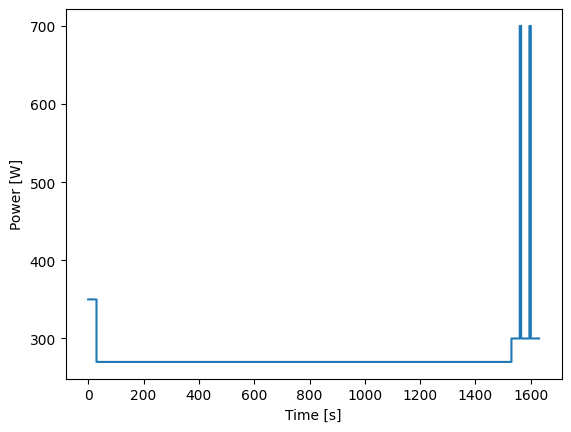

In [11]:
power_req = np.array([350, 350, 270, 270, 300, 300, 700, 700, 300, 300, 700, 700, 300, 300])
time =np.array([   0.  ,   30.  ,   30.01, 1530.  , 1530.01, 1560.  , 1560.01, 1565.  , 1565.01, 1595., 1595.01, 1600, 1600.01, 1630])

plt.plot(time, power_req)
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")

energy_J = np.trapz(power_req, time)
energy_kWh = energy_J / (3600 * 1000)

In [12]:
molicel_power_capacity = 16.2 #spec sheet Wh
molicel_peak_power = 150 # 180 - 90% SOC - 10s

LG_power_capacity = 18.2 #spec sheet - Wh
LG_peak_power = 50 # pulse - 80 W - 10s - low SOC

n_cells_moli = energy_kWh * 1000 / molicel_power_capacity
n_cells_power_moli = max(power_req)/ molicel_peak_power
print(f"Molicel P45B \n Energy limited case: {np.ceil(n_cells_moli)}, Power limited case: {np.ceil(n_cells_power_moli)}")

n_cells_lg = energy_kWh * 1000 / LG_power_capacity
n_cells_power_lg = max(power_req)/LG_peak_power
print(f"LG-M50 \n Energy limited case: {np.ceil(n_cells_lg)}, Power limited case: {np.ceil(n_cells_power_lg)}")

Molicel P45B 
 Energy limited case: 8.0, Power limited case: 5.0
LG-M50 
 Energy limited case: 7.0, Power limited case: 14.0


For the LGM50 cell we are clearly power limited. For the Molicel we are energy limited, however the number of cells from the energy and peak power calculations are close.

### LG-M50

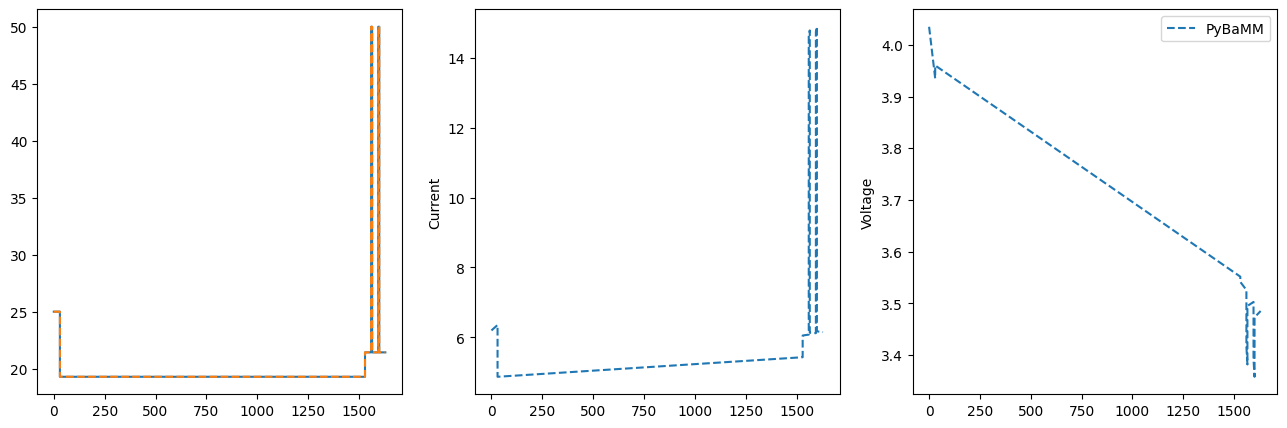

In [13]:
from params_lgm50 import get_parameter_values as lg_param_values

power_cell = np.array(power_req) / np.ceil(n_cells_power_lg)

power_interpolant = pybamm.Interpolant(np.array(time), power_cell, pybamm.t)
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})
params = lg_param_values()
params.update({"Power function [W]": power_interpolant}, check_already_exists=False)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=params, solver=solver)
soln = sim.solve(t_eval=np.array(time), t_interp=np.array(time), initial_soc=1.0)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].plot(time, power_cell)
ax[0].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries*soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Power")
ax[1].plot(soln["Time [s]"].entries, soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Current")
ax[2].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="PyBaMM", linestyle="--")
ax[2].set_ylabel("Voltage")
plt.legend()
plt.show()

Text(0, 0.5, 'Positive electrode potential [V]')

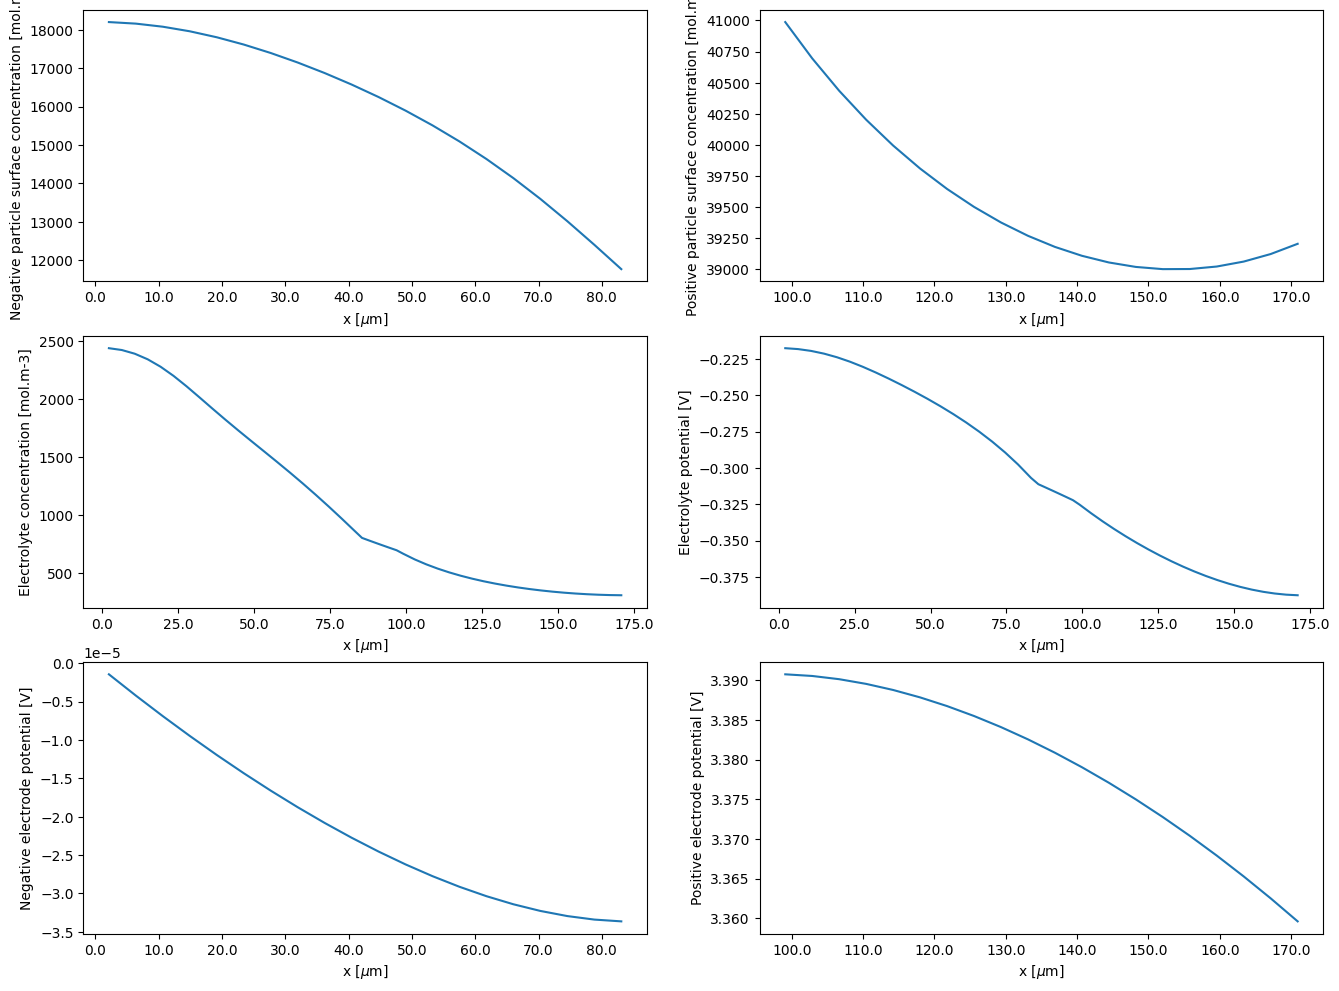

In [14]:
import matplotlib.ticker as ticker
idx_max_current = np.argmax(soln["Current [A]"].entries)
fig, ax = plt.subplots(3, 2, figsize=(16, 12))

x_mesh = np.concatenate((sim.mesh["negative electrode"].nodes, sim.mesh["separator"].nodes, sim.mesh["positive electrode"].nodes))
pos_mesh = sim.mesh["positive electrode"].nodes
neg_mesh = sim.mesh["negative electrode"].nodes

formatter = lambda x, pos: f'{x:.1f}'
for axis in ax.ravel():
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(formatter))
    axis.set_xlabel(r"x [$\mu$m]")

ax[0][1].plot(pos_mesh*10**6, soln["Positive particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][1].set_ylabel("Positive particle surface concentration [mol.m-3]")

ax[0][0].plot(neg_mesh*10**6, soln["Negative particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][0].set_ylabel("Negative particle surface concentration [mol.m-3]")

ax[1][0].plot(x_mesh*10**6, soln["Electrolyte concentration [mol.m-3]"].entries[:, idx_max_current])
ax[1][0].set_ylabel("Electrolyte concentration [mol.m-3]")


ax[1][1].plot(x_mesh*10**6, soln["Electrolyte potential [V]"].entries[:, idx_max_current])
ax[1][1].set_ylabel("Electrolyte potential [V]")

ax[2][0].plot(neg_mesh*10**6, soln["Negative electrode potential [V]"].entries[:, idx_max_current])
ax[2][0].set_ylabel("Negative electrode potential [V]")


ax[2][1].plot(pos_mesh*10**6, soln["Positive electrode potential [V]"].entries[:, idx_max_current])
ax[2][1].set_ylabel("Positive electrode potential [V]")

### Molicel P45B

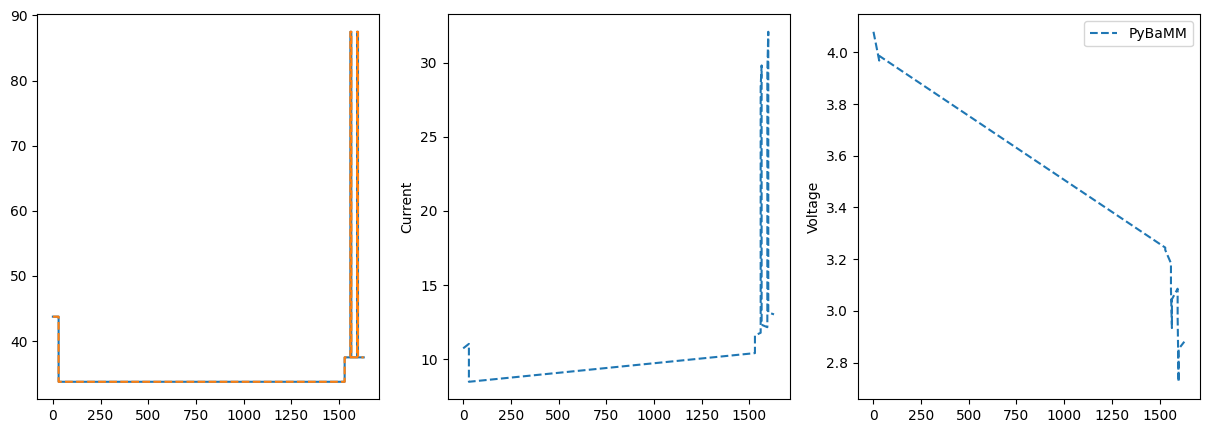

In [15]:
from params_p45b import get_parameter_values as p45b_param_values

power_cell = np.array(power_req) / np.ceil(n_cells_moli)

power_interpolant = pybamm.Interpolant(np.array(time), power_cell, pybamm.t)
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})
params = p45b_param_values()
params.update({"Power function [W]": power_interpolant}, check_already_exists=False)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=params, solver=solver)
soln = sim.solve(t_eval=np.array(time), t_interp=np.array(time), initial_soc=1.0)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(time, power_cell)
ax[0].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries*soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Power")
ax[1].plot(soln["Time [s]"].entries, soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Current")
ax[2].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="PyBaMM", linestyle="--")
ax[2].set_ylabel("Voltage")
plt.legend()
plt.show()

Text(0, 0.5, 'Positive electrode potential [V]')

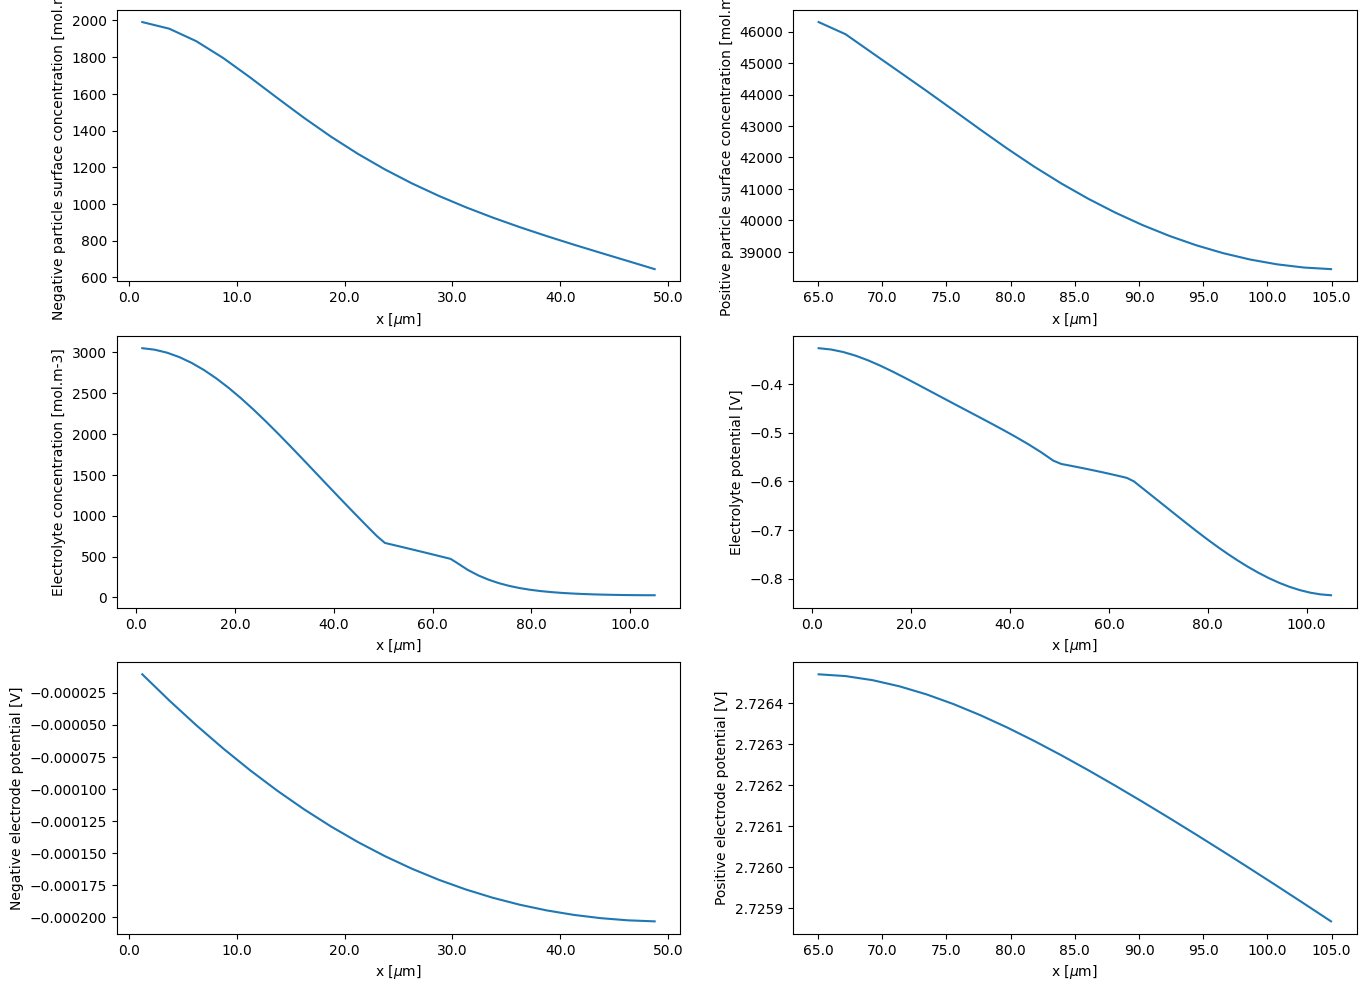

In [16]:
import matplotlib.ticker as ticker
idx_max_current = np.argmax(soln["Current [A]"].entries)
fig, ax = plt.subplots(3, 2, figsize=(16, 12))

x_mesh = np.concatenate((sim.mesh["negative electrode"].nodes, sim.mesh["separator"].nodes, sim.mesh["positive electrode"].nodes))
pos_mesh = sim.mesh["positive electrode"].nodes
neg_mesh = sim.mesh["negative electrode"].nodes

formatter = lambda x, pos: f'{x:.1f}'
for axis in ax.ravel():
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(formatter))
    axis.set_xlabel(r"x [$\mu$m]")

ax[0][1].plot(pos_mesh*10**6, soln["Positive particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][1].set_ylabel("Positive particle surface concentration [mol.m-3]")

ax[0][0].plot(neg_mesh*10**6, soln["Negative particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][0].set_ylabel("Negative particle surface concentration [mol.m-3]")

ax[1][0].plot(x_mesh*10**6, soln["Electrolyte concentration [mol.m-3]"].entries[:, idx_max_current])
ax[1][0].set_ylabel("Electrolyte concentration [mol.m-3]")


ax[1][1].plot(x_mesh*10**6, soln["Electrolyte potential [V]"].entries[:, idx_max_current])
ax[1][1].set_ylabel("Electrolyte potential [V]")

ax[2][0].plot(neg_mesh*10**6, soln["Negative electrode potential [V]"].entries[:, idx_max_current])
ax[2][0].set_ylabel("Negative electrode potential [V]")


ax[2][1].plot(pos_mesh*10**6, soln["Positive electrode potential [V]"].entries[:, idx_max_current])
ax[2][1].set_ylabel("Positive electrode potential [V]")

## Pyka - Pelican

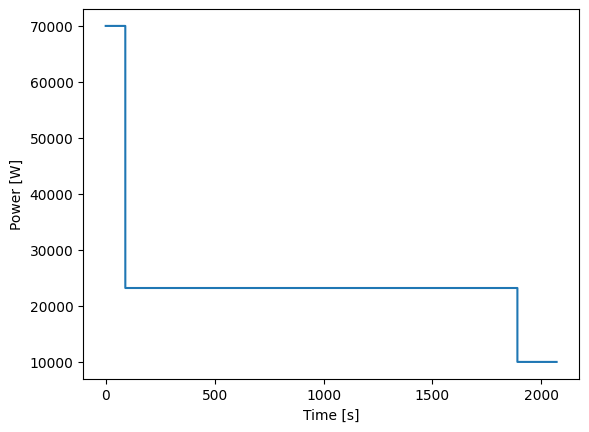

In [17]:
power_req = np.array([70000, 70000, 23200, 23200, 10000, 10000])
time = np.array([0.0, 90, 90.1, 30*60 + 90, 1890.01, 1890.01+180])

plt.plot(time, power_req)
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")

energy_J = np.trapz(power_req, time)
energy_kWh = energy_J / (3600 * 1000)

In [18]:
molicel_power_capacity = 16.2 #spec sheet Wh
molicel_peak_power = 150 # 180 - 90% SOC - 10s, continuous at high SOC

LG_power_capacity = 18.2 #spec sheet - Wh
LG_peak_power = 50 # pulse - 80 W - 10s - we want continuous power at high SOC

n_cells_moli = energy_kWh * 1000 / molicel_power_capacity
n_cells_power_moli = max(power_req)/ molicel_peak_power
print(f"Molicel P45B \n Energy limited case: {np.ceil(n_cells_moli)}, Power limited case: {np.ceil(n_cells_power_moli)}")

n_cells_lg = energy_kWh * 1000 / LG_power_capacity
n_cells_power_lg = max(power_req)/LG_peak_power
print(f"LG-M50 \n Energy limited case: {np.ceil(n_cells_lg)}, Power limited case: {np.ceil(n_cells_power_lg)}")

Molicel P45B 
 Energy limited case: 855.0, Power limited case: 467.0
LG-M50 
 Energy limited case: 762.0, Power limited case: 1400.0


In the case of the aircraft, similar to the Skydio drone we are clearly power limited in the case of the LGM50 and energy limited in the case of the Molicel.

### LG-M50

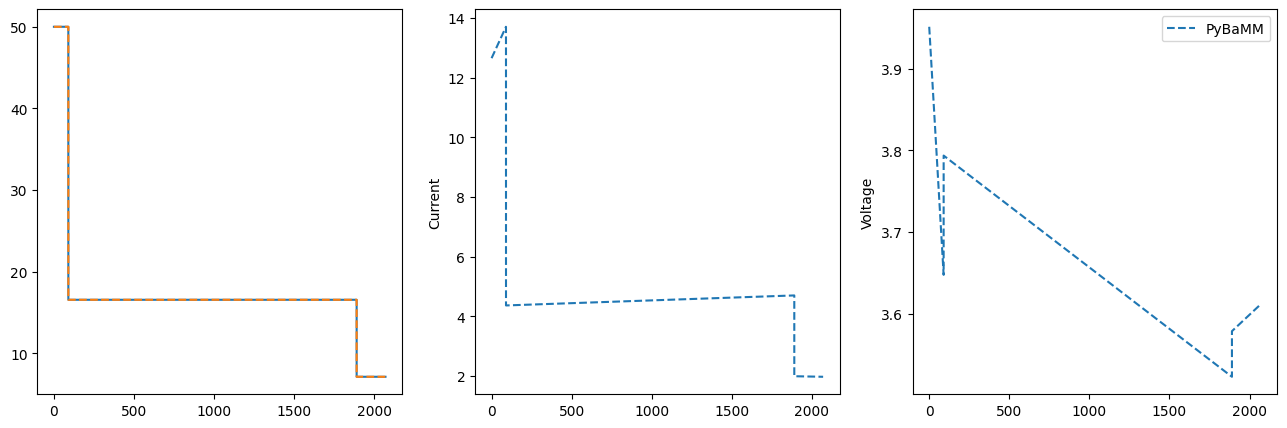

In [19]:
from params_lgm50 import get_parameter_values as lg_param_values

power_cell = np.array(power_req) / np.ceil(n_cells_power_lg)

power_interpolant = pybamm.Interpolant(np.array(time), power_cell, pybamm.t)
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})
params = lg_param_values()
params.update({"Power function [W]": power_interpolant}, check_already_exists=False)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=params, solver=solver)
soln = sim.solve(t_eval=np.array(time), t_interp=np.array(time), initial_soc=1.0)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].plot(time, power_cell)
ax[0].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries*soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Power")
ax[1].plot(soln["Time [s]"].entries, soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Current")
ax[2].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="PyBaMM", linestyle="--")
ax[2].set_ylabel("Voltage")
plt.legend()
plt.show()

Text(0, 0.5, 'Positive electrode potential [V]')

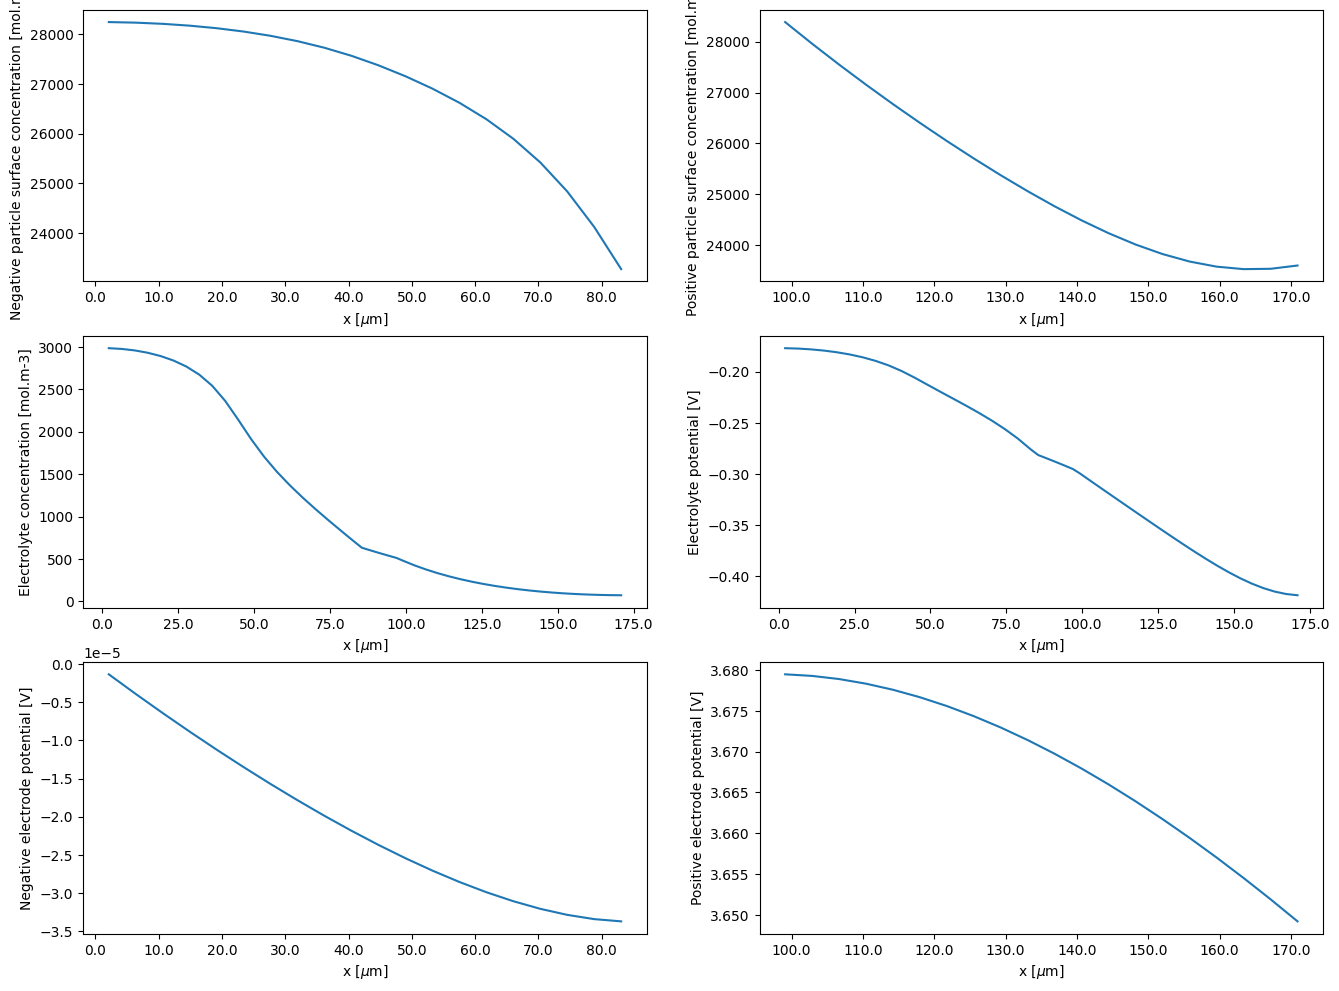

In [20]:
import matplotlib.ticker as ticker
idx_max_current = np.argmax(soln["Current [A]"].entries)
fig, ax = plt.subplots(3, 2, figsize=(16, 12))

x_mesh = np.concatenate((sim.mesh["negative electrode"].nodes, sim.mesh["separator"].nodes, sim.mesh["positive electrode"].nodes))
pos_mesh = sim.mesh["positive electrode"].nodes
neg_mesh = sim.mesh["negative electrode"].nodes

formatter = lambda x, pos: f'{x:.1f}'
for axis in ax.ravel():
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(formatter))
    axis.set_xlabel(r"x [$\mu$m]")

ax[0][1].plot(pos_mesh*10**6, soln["Positive particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][1].set_ylabel("Positive particle surface concentration [mol.m-3]")

ax[0][0].plot(neg_mesh*10**6, soln["Negative particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][0].set_ylabel("Negative particle surface concentration [mol.m-3]")

ax[1][0].plot(x_mesh*10**6, soln["Electrolyte concentration [mol.m-3]"].entries[:, idx_max_current])
ax[1][0].set_ylabel("Electrolyte concentration [mol.m-3]")


ax[1][1].plot(x_mesh*10**6, soln["Electrolyte potential [V]"].entries[:, idx_max_current])
ax[1][1].set_ylabel("Electrolyte potential [V]")

ax[2][0].plot(neg_mesh*10**6, soln["Negative electrode potential [V]"].entries[:, idx_max_current])
ax[2][0].set_ylabel("Negative electrode potential [V]")


ax[2][1].plot(pos_mesh*10**6, soln["Positive electrode potential [V]"].entries[:, idx_max_current])
ax[2][1].set_ylabel("Positive electrode potential [V]")

### Molicel P45B

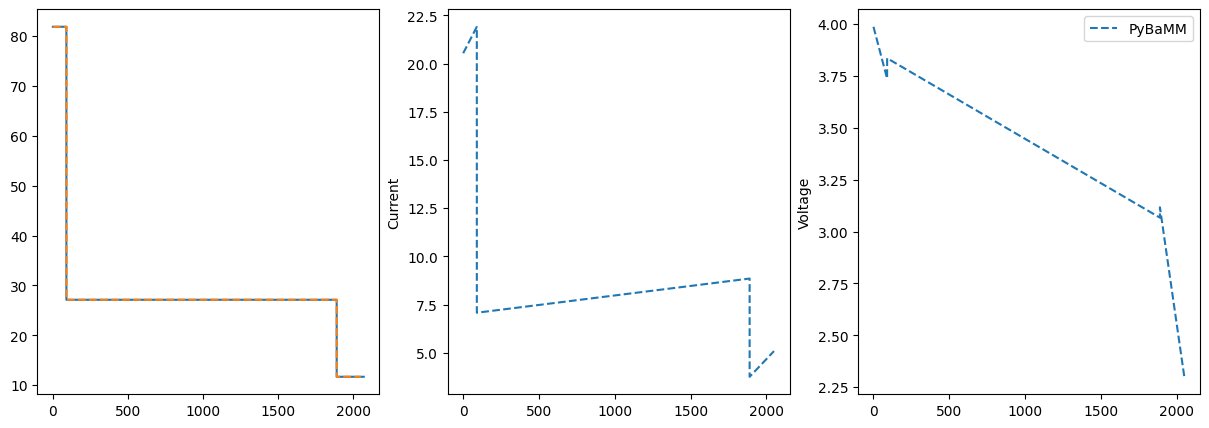

In [21]:
from params_p45b import get_parameter_values as p45b_param_values

power_cell = np.array(power_req) / np.ceil(n_cells_moli)

power_interpolant = pybamm.Interpolant(np.array(time), power_cell, pybamm.t)
model = pybamm.lithium_ion.DFN(options={"operating mode": "power"})
params = p45b_param_values()
params.update({"Power function [W]": power_interpolant}, check_already_exists=False)

solver = pybamm.IDAKLUSolver()
sim = pybamm.Simulation(model, parameter_values=params, solver=solver)
soln = sim.solve(t_eval=np.array(time), t_interp=np.array(time), initial_soc=1.0)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(time, power_cell)
ax[0].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries*soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Power")
ax[1].plot(soln["Time [s]"].entries, soln["Current [A]"].entries, label="PyBaMM", linestyle="--")
ax[1].set_ylabel("Current")
ax[2].plot(soln["Time [s]"].entries, soln["Voltage [V]"].entries, label="PyBaMM", linestyle="--")
ax[2].set_ylabel("Voltage")
plt.legend()
plt.show()

Text(0, 0.5, 'Positive electrode potential [V]')

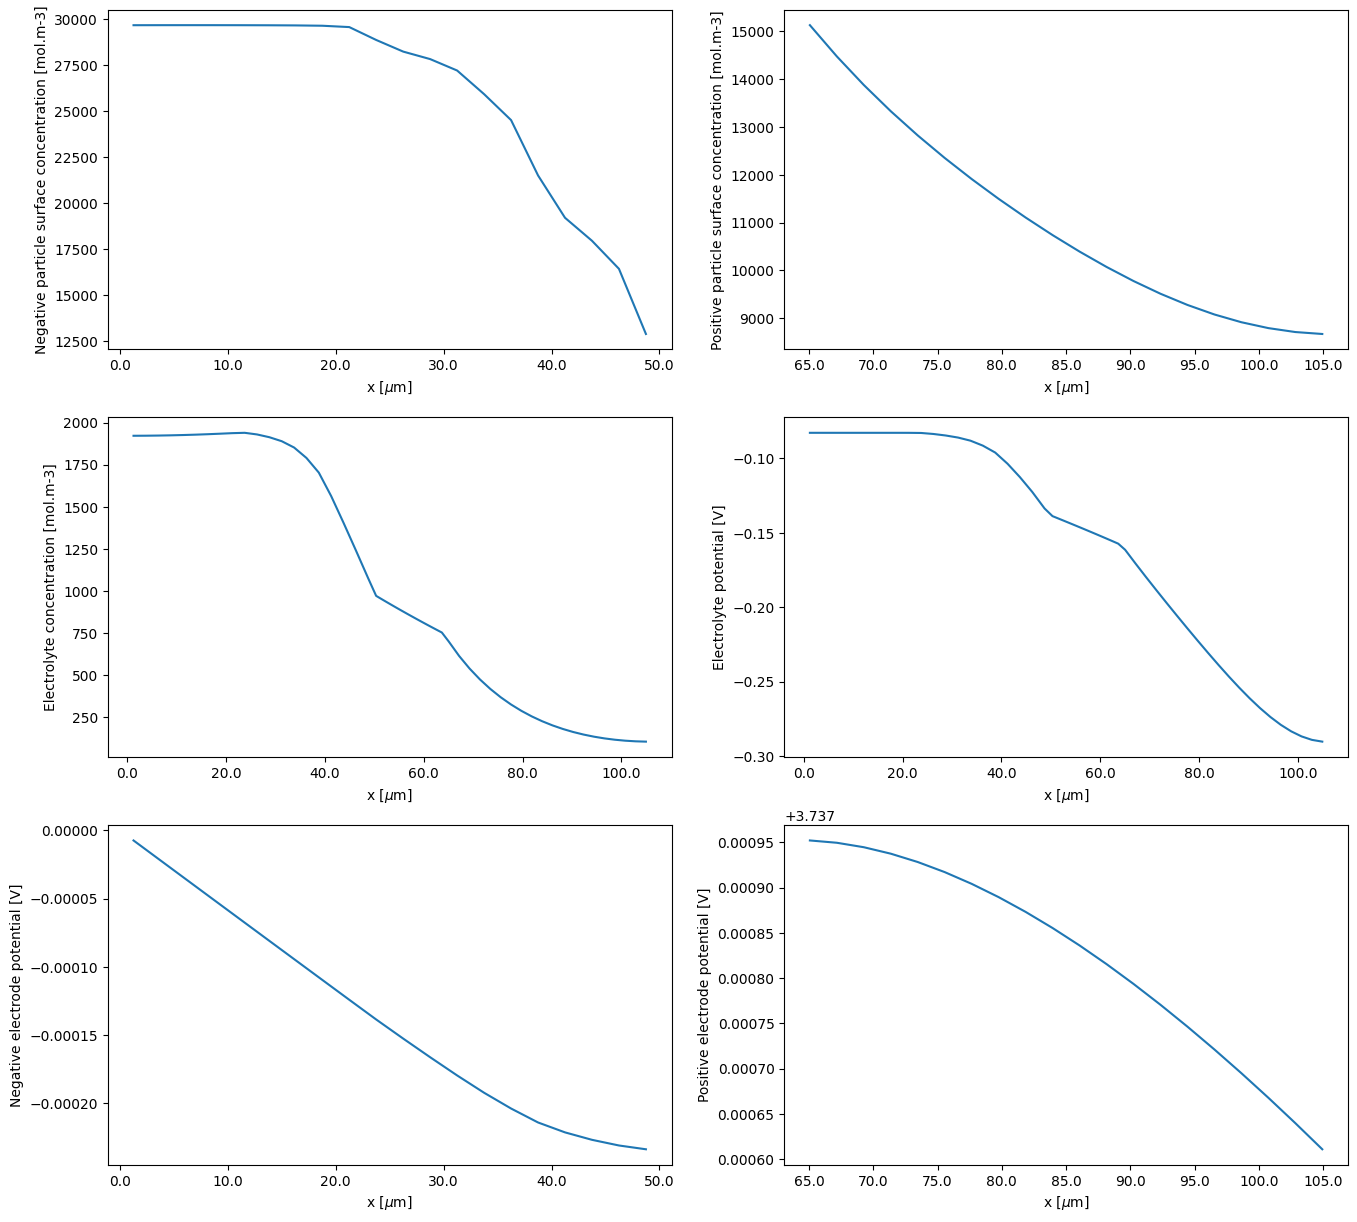

In [22]:
import matplotlib.ticker as ticker
idx_max_current = np.argmax(soln["Current [A]"].entries)
fig, ax = plt.subplots(3, 2, figsize=(16, 15))

x_mesh = np.concatenate((sim.mesh["negative electrode"].nodes, sim.mesh["separator"].nodes, sim.mesh["positive electrode"].nodes))
pos_mesh = sim.mesh["positive electrode"].nodes
neg_mesh = sim.mesh["negative electrode"].nodes

formatter = lambda x, pos: f'{x:.1f}'
for axis in ax.ravel():
    axis.xaxis.set_major_formatter(ticker.FuncFormatter(formatter))
    axis.set_xlabel(r"x [$\mu$m]")

ax[0][1].plot(pos_mesh*10**6, soln["Positive particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][1].set_ylabel("Positive particle surface concentration [mol.m-3]")

ax[0][0].plot(neg_mesh*10**6, soln["Negative particle surface concentration [mol.m-3]"].entries[:, idx_max_current])
ax[0][0].set_ylabel("Negative particle surface concentration [mol.m-3]")

ax[1][0].plot(x_mesh*10**6, soln["Electrolyte concentration [mol.m-3]"].entries[:, idx_max_current])
ax[1][0].set_ylabel("Electrolyte concentration [mol.m-3]")


ax[1][1].plot(x_mesh*10**6, soln["Electrolyte potential [V]"].entries[:, idx_max_current])
ax[1][1].set_ylabel("Electrolyte potential [V]")

ax[2][0].plot(neg_mesh*10**6, soln["Negative electrode potential [V]"].entries[:, idx_max_current])
ax[2][0].set_ylabel("Negative electrode potential [V]")


ax[2][1].plot(pos_mesh*10**6, soln["Positive electrode potential [V]"].entries[:, idx_max_current])
ax[2][1].set_ylabel("Positive electrode potential [V]")